In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [2]:
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, n_informative=4, n_redundant=6, n_repeated=0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### Logistic Regression classification

In [24]:
model = LogisticRegression()
model.fit(X_train, y_train)
from sklearn.metrics import classification_report, roc_auc_score
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
y_pred_proba = model.predict_proba(X_test)[:, 1]    
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.66      0.69      0.67       122
           1       0.69      0.66      0.68       128

    accuracy                           0.68       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.68      0.68      0.68       250

ROC AUC Score: 0.7649


In [25]:
probabilities = model.predict_proba(X_test)[:, 1]

y_pred = (probabilities >= 0.2634958527222966).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.30      0.42       122
           1       0.57      0.91      0.70       128

    accuracy                           0.61       250
   macro avg       0.66      0.60      0.56       250
weighted avg       0.66      0.61      0.57       250



In [26]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
print(fpr[:5], tpr[:5], thresholds[:5])

roc_auc = auc(fpr, tpr)
print(f"ROC AUC Score: {roc_auc:.4f}")

[0.         0.         0.         0.00819672 0.00819672] [0.        0.0078125 0.265625  0.265625  0.2890625] [       inf 0.97928246 0.80890214 0.80840719 0.80207033]
ROC AUC Score: 0.7649


In [27]:
desired_recall= 0.8
closest_index = abs(tpr - desired_recall).argmin()


In [28]:
threshold_at_desired_recall = thresholds[closest_index]
threshold_at_desired_recall, fpr[closest_index], tpr[closest_index]


(np.float64(0.42366894057938426),
 np.float64(0.4180327868852459),
 np.float64(0.796875))

In [29]:
area = auc(fpr, tpr)

area

np.float64(0.764856557377049)

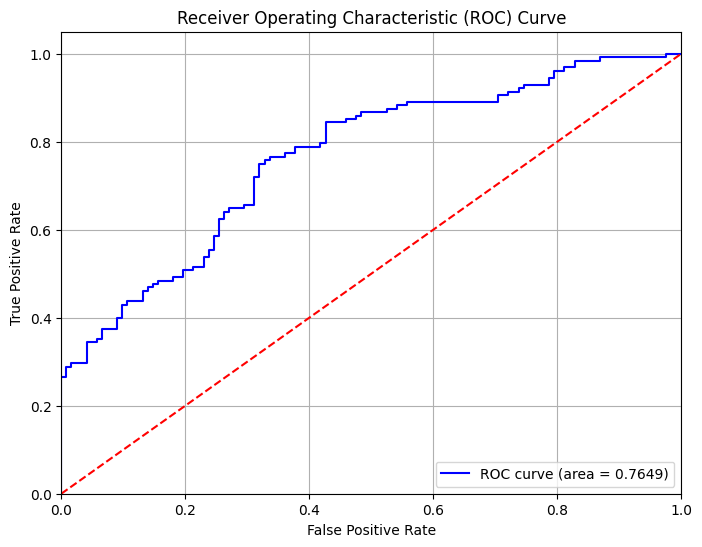

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {area:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()

In [32]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(classification_report(y_test, y_pred_xgb))
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}")

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       122
           1       0.94      0.88      0.91       128

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

XGBoost ROC AUC Score: 0.9501


c:\Office_Data\Prsonal data\Prsonal data\Resume\myrepo\GenAIAndMachineLearningProjects\PracticeCode\.venv\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


In [33]:
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_score_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb) 
roc_auc_xgb

np.float64(0.9501152663934426)

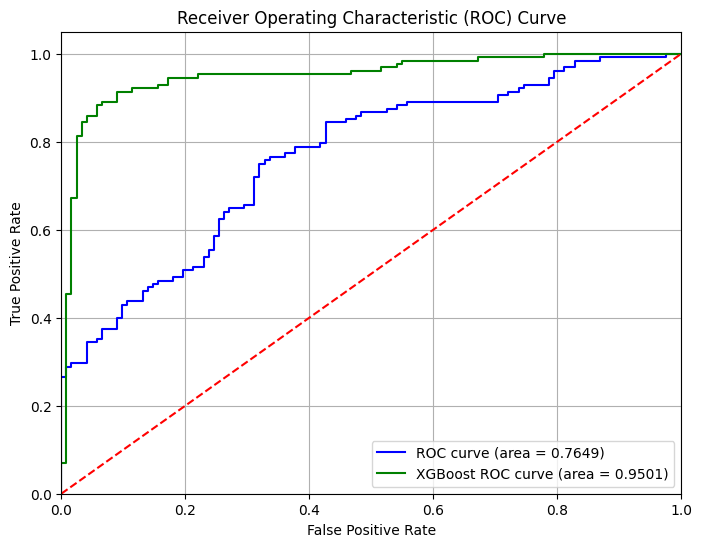

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {area:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', label=f'XGBoost ROC curve (area = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [36]:
desired_recall = 0.92
closest_index_xgb = abs(tpr_xgb - desired_recall).argmin()
threshold_at_desired_recall_xgb = thresholds_xgb[closest_index_xgb]
threshold_at_desired_recall_xgb, fpr_xgb[closest_index_xgb], tpr_xgb[closest_index_xgb]


(np.float32(0.3286321), np.float64(0.11475409836065574), np.float64(0.921875))